# PS2.2: Cycle-Consistent Adversarial Networks (CycleGAN)
In this notebook, you will implement the paper [
Unpaired Image-to-Image Translation using Cycle-Consistent Adversarial Networks by Zhu et. al.](https://arxiv.org/abs/1703.10593). The problem set focuses on the **apple2orange** dataset because it is visually distinct, and small enough to train reasonably well on a Colab GPU.

**Goals:**

1.   Implement the generator
2.   Implement the discriminator
3.   Implement the loss functions
4.   Translate apples to oranges and back.

## Setup and Imports

In [3]:
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
import torchvision.utils as vutils
from PIL import Image
import matplotlib.pyplot as plt
import itertools
from tqdm import tqdm
import numpy as np
import random

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

Using device: cuda


## Useful Functions for Debugging

In [4]:
def reset_seed(number):
    """
    Reset random seed to the specific number

    Inputs:
    - number: A seed number to use
    """
    random.seed(number)
    torch.manual_seed(number)
    return


def rel_error(x, y, eps=1e-10):
    """
    Compute the relative error between a pair of tensors x and y,
    which is defined as:

                            max_i |x_i - y_i]|
    rel_error(x, y) = -------------------------------
                      max_i |x_i| + max_i |y_i| + eps

    Inputs:
    - x, y: Tensors of the same shape
    - eps: Small positive constant for numeric stability

    Returns:
    - rel_error: Scalar giving the relative error between x and y
    """
    """ returns relative error between x and y """
    top = (x - y).abs().max().item()
    bot = (x.abs() + y.abs()).clamp(min=eps).max().item()
    return top / bot

def count_parameters(model):
    """Finds the total number of trainable parameters in a model.
    """
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

## Download Apple2Orange Dataset

In [5]:
# Download dataset
if not os.path.exists('datasets/apple2orange'):
    print("Downloading dataset...")
    !wget -N https://efrosgans.eecs.berkeley.edu/cyclegan/datasets/apple2orange.zip -O apple2orange.zip
    !unzip -q apple2orange.zip -d datasets/
    !rm apple2orange.zip
    print("Dataset downloaded and unzipped.")
else:
    print("Dataset already exists.")

Dataset already exists.


## Dataset Class and Data Loading

In [6]:
class ImageDataset(torch.utils.data.Dataset):
    def __init__(self, root, transforms_=None, mode='train'):
        self.transform = transforms.Compose(transforms_)
        self.files_A = sorted([os.path.join(root, f'{mode}A', x) for x in os.listdir(os.path.join(root, f'{mode}A')) if x.endswith('.jpg')])
        self.files_B = sorted([os.path.join(root, f'{mode}B', x) for x in os.listdir(os.path.join(root, f'{mode}B')) if x.endswith('.jpg')])

    def __getitem__(self, index):
        # CycleGAN uses unpaired data, so we use random indices if lengths differ
        img_A = self.transform(Image.open(self.files_A[index % len(self.files_A)]).convert('RGB'))
        img_B = self.transform(Image.open(self.files_B[index % len(self.files_B)]).convert('RGB')) # Naive pairing for simplicity
        return {'A': img_A, 'B': img_B}

    def __len__(self):
        return max(len(self.files_A), len(self.files_B))

# Hyperparameters
IMAGE_SIZE = 128
BATCH_SIZE = 4

# Transforms
transforms_ = [
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
]

train_dataloader = DataLoader(
    ImageDataset("datasets/apple2orange", transforms_=transforms_, mode='train'),
    batch_size=BATCH_SIZE, shuffle=True, num_workers=2
)
test_dataloader = DataLoader(
    ImageDataset("datasets/apple2orange", transforms_=transforms_, mode='test'),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=2
)

## Visualize the data

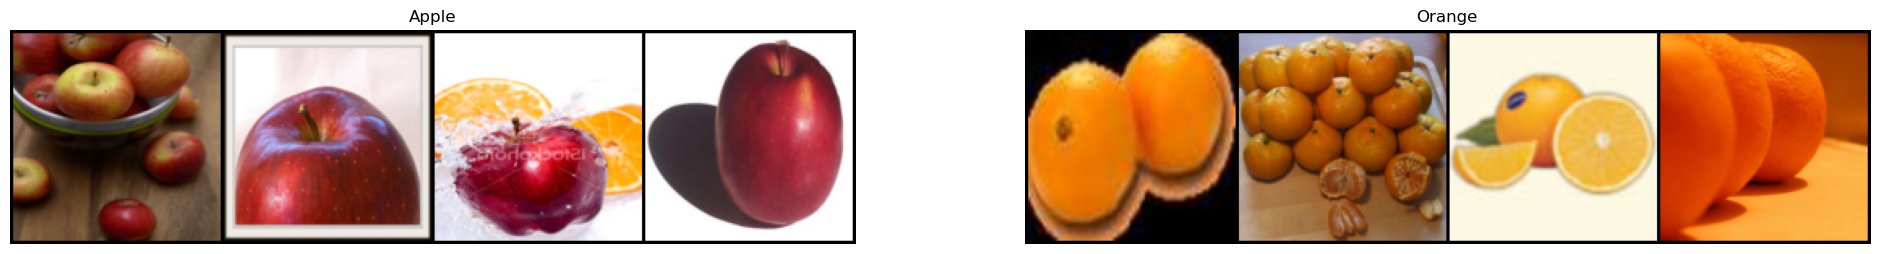

In [5]:
reset_seed(42)

vis_batch = next(iter(train_dataloader))
plt.figure(figsize=(24, 30))
plt.subplot(1, 2, 1)
plt.imshow(
    np.transpose(
        vutils.make_grid(
            vis_batch["A"].to(device)[:64], padding=2, normalize=True
        ).cpu(),
        (1, 2, 0),
    )
)
plt.title("Apple")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(
    np.transpose(
        vutils.make_grid(
            vis_batch["B"].to(device)[:64], padding=2, normalize=True
        ).cpu(),
        (1, 2, 0),
    )
)
plt.title("Orange")
plt.axis('off')
plt.show()

## Part 1: The Discriminator (PatchGAN)
Implement a discriminator that classifies patches of an image as real or fake. For the discriminator networks we follow the paper to use $70 \times 70$ PatchGANs. Let $Ck$ denote a $4 \times 4$ Convolution-InstanceNorm-LeakyReLU layer with $k$ filters and stride 2. After the last layer, we apply a convolution to produce a 1-dimensional output. We do not use InstanceNorm for the first $C64$ layer. We use leaky ReLUs with a slope of 0.2. The discriminator architecture is: $C64-C128-C256-C512$.

In [7]:
class Discriminator(nn.Module):
    def __init__(self, in_channels=3):
        super(Discriminator, self).__init__()

        def discriminator_block(in_filters, out_filters, normalize=True, stride=2):
            """Returns layers of each discriminator block"""
            ###########################################################################
            # TODO: Implement the 4×4  Convolution-InstanceNorm-LeakyReLU layer       #
            # with 𝑘 filters and stride 2.                                            #
            # Hint: Use nn.Conv2d, nn.InstanceNorm2d, nn.LeakyReLU                    #
            ###########################################################################

            layers = [
                nn.Conv2d(in_filters, out_filters, 4, stride=stride, padding=1),
                nn.LeakyReLU(0.2, inplace=True),
            ]

            if normalize:
                layers.insert(1, nn.InstanceNorm2d(out_filters))

            ###########################################################################
            #                             END OF YOUR CODE                            #
            ###########################################################################
            return layers

        ######################################################################################
        # TODO: Implement the PatchGAN architecture                                          #
        # It typically consists of 3-4 discriminator blocks followed by a final convolution. #
        # Suggested structure:                                                               #
        # 1. Block: in_channels -> 64 (normalization=False)                                  #
        # 2. Block: 64 -> 128                                                                #
        # 3. Block: 128 -> 256                                                               #
        # 4. Block: 256 -> 512                                                               #
        # 5. Final Conv2d layer: 512 -> 1 output channel (4x4 kernel, padding=1)             #
        # Hint: self.model = nn.Sequential(...)
        ######################################################################################

        self.model = nn.Sequential(
            *discriminator_block(in_channels, 64, normalize=False),
            *discriminator_block(64, 128),
            *discriminator_block(128, 256),
            *discriminator_block(256, 512),
            nn.ZeroPad2d((1, 0, 1, 0)),
            nn.Conv2d(512, 1, 4, padding=1)
        )

        ######################################################################################
        #                                  END OF YOUR CODE                                  #
        ######################################################################################

    def forward(self, img):
        return self.model(img)

## Discriminator Sanity Check

If your implementation is correct, the number of discriminator's parameters should be $2764737$. And the rel_error between the gt_output and test_output should be less than `1e-4`.

In [37]:
reset_seed(42)

D_test = Discriminator()
num_params = count_parameters(D_test)
gt_num_params = 2764737
print("GT num_params: ", gt_num_params, ", num_params: ", num_params)

D_test.eval()
with torch.no_grad():
    test_input = torch.ones((1, 3, 32, 32))
    test_output = D_test(test_input)

gt_output = torch.tensor([[-0.0873, -0.4523], [0.1912, -0.0059]])
print("Error: ", rel_error(gt_output, test_output))

GT num_params:  2764737 , num_params:  2764737
Error:  4.1084482743397064e-05


## Part 2: The Generator (ResNet-based)
Implement a ResNet-based generator that transforms images from domain X to Y. For the generator networks we follow the paper's implementation. Let $c7s1-k$ denote a $7 \times 7$ Convolution-InstanceNorm-ReLU layer with $k$ filters and stride 1. $dk$ denotes a $3 \times 3$ Convolution-InstanceNorm-ReLU layer with k filters and stride 2. Reflection padding was used to reduce artifacts. $Rk$ denotes a residual block that contains two $3 \times 3$ convolutional layers with the same number of filters on both layer. $uk$ denotes a $3 \times 3$ fractional-strided-ConvolutionInstanceNorm-ReLU layer with $k$ filters and stride $\frac{1}{2}$. The network with 6 residual blocks consists of: $c7s1-64 , d128, d256, R256, R256, R256, R256, R256, R256,u128, u64, c7s1-3$

### Residual block

we will use the Convolutional Layer with **Reflection Padding** and **Instance Norm** . Architecture for the **ResidualBlock** is described below:


 * `Reflection Padding` (Hint: nn.ReflectionPad2d)
 * Convolutional Layer
 * `InstanceNorm2d` (Hint: nn.InstanceNorm2d)
 * `ReLU`
 * `Reflection Padding` (Hint: nn.ReflectionPad2d)
 * Convolutional Layer
 * `InstanceNorm2d` (Hint: nn.InstanceNorm2d)

In [8]:
class ResidualBlock(nn.Module):
    def __init__(self, in_features):
        super(ResidualBlock, self).__init__()
        ###########################################################################
        # TODO: Implement the residual block described above                      #
        # Hint: self.block = nn.Sequential(...)                                   #
        ###########################################################################

        self.block = nn.Sequential(
            nn.ReflectionPad2d(1),
            nn.Conv2d(in_features, in_features, 3),
            nn.InstanceNorm2d(in_features),
            nn.ReLU(inplace=True),
            nn.ReflectionPad2d(1),
            nn.Conv2d(in_features, in_features, 3),
            nn.InstanceNorm2d(in_features)
        )

        ###########################################################################
        #                              END OF YOUR CODE                           #
        ###########################################################################

    def forward(self, x):
        return x + self.block(x)

### ResidualBlock Sanity Check

If your implementation is correct, the number of parameters of a ResidualBlock with **in_features=3** should be $168$.

In [9]:
test_residual_block = ResidualBlock(in_features=3)
print("GT num parameters: 168, num parameters: ", count_parameters(test_residual_block))

GT num parameters: 168, num parameters:  168


## Generator

Now lets start building our Generator network. We can divide the whole generator into 5 parts as follows:

### Part(a): Initial Convolution

Here we will be implementing the $c7s1-64$. Architecture for $c7s1-64$ is described below:

 * `Reflection Padding` (Hint: nn.ReflectionPad2d)
 * Convolutional Layer
 * `InstanceNorm2d` (Hint: nn.InstanceNorm2d)
 * `ReLU`

### Part(b): Downsampling

Here we will be implementing the $d128$ and $d256$. Architecture for $dk$ is described below:

 * Convolutional Layer
 * `InstanceNorm2d` (Hint: nn.InstanceNorm2d)
 * `ReLU`

 ### Part(c): Adding Residual Blocks

Here we will be adding $9$ ResidualBlocks to the generator.

### Part(d): Upsampling

Here we will be implementing the $u128$ and $u64$. Architecture for $uk$ is described below:

 * Transposed Convolutional Layer (Hint: nn.ConvTranspose2d)
 * `InstanceNorm2d` (Hint: nn.InstanceNorm2d)
 * `ReLU`

 ### Part(e): Output Layer

 Here we will be implementing the $c7s1-3$. Architecture for $c7s1-3$ is described below:

* `Reflection Padding` (Hint: nn.ReflectionPad2d)
 * Convolutional Layer
 * `Tanh`

In [27]:
class Generator(nn.Module):
    def __init__(self, in_channels=3, out_channels=3, num_residual_blocks=6):
        super(Generator, self).__init__()
        model = []

        #########################################################################
        # TODO: Implement Part(a) Initial Convolution.                          #
        #########################################################################

        model += [
            nn.ReflectionPad2d(3),
            nn.Conv2d(in_channels, 64, 7),
            nn.InstanceNorm2d(64),
            nn.ReLU(inplace=True)
        ]

        #########################################################################
        #                            END OF YOUR CODE                           #
        #########################################################################

        #########################################################################
        # TODO: Implement Part(b) Downsampling.                                 #
        #                                                                       #
        # Hint:                                                                 #
        # in_features = 64                                                      #
        # out_features = ...                                                    #
        # for _ in range(2):                                                    #
        #     model += ...                                                      #
        #     in_features = ...                                                 #
        #     out_features = ...                                                #
        #########################################################################

        in_features = 64
        for _ in range(2):
            out_features = in_features * 2
            model += [
                nn.Conv2d(in_features, out_features, 3, stride=2, padding=1),
                nn.InstanceNorm2d(out_features),
                nn.ReLU(inplace=True)
            ]
            in_features = out_features

        #########################################################################
        #                            END OF YOUR CODE                           #
        #########################################################################

        #########################################################################
        # TODO: Implement Part(c) Adding the ResidualBlocks.                    #
        #########################################################################

        for _ in range(num_residual_blocks):
            model += [ResidualBlock(in_features)]

        #########################################################################
        #                            END OF YOUR CODE                           #
        #########################################################################

        #########################################################################
        # TODO: Implement Part(d) Upsampling.                                   #
        #                                                                       #
        # Hint:                                                                 #
        # out_features = ...                                                    #
        # for _ in range(2):                                                    #
        #     model += ...                                                      #
        #     in_features = ...                                                 #
        #     out_features = ...                                                #
        #########################################################################

        for _ in range(2):
            out_features = in_features // 2
            model += [
                nn.ConvTranspose2d(in_features, out_features, 3, stride=2, padding=1, output_padding=1),
                nn.InstanceNorm2d(out_features),
                nn.ReLU(inplace=True)
            ]
            in_features = out_features

        #########################################################################
        #                            END OF YOUR CODE                           #
        #########################################################################

        #########################################################################
        # TODO: Implement Pard(e) Output Layer.                                 #
        #########################################################################

        model += [
            nn.ReflectionPad2d(3),
            nn.Conv2d(in_features, 3, 7, stride=1),
            nn.Tanh()
        ]

        #########################################################################
        #                            END OF YOUR CODE                           #
        #########################################################################

        self.model = nn.Sequential(*model)

    def forward(self, x):
        return self.model(x)

## Generator Sanity Check

If your implementation is correct, the number of generator's parameters should be $7837699$.

In [28]:
reset_seed(42)

test_generator = Generator()
print("GT num parameters: 7837699, num parameters: ", count_parameters(test_generator))

GT num parameters: 7837699, num parameters:  7837699


## Part 3: Loss Functions
Implement the specific loss logic for CycleGAN.

### Generator Loss Functions
The Generator Loss is composed of 3 parts. They are described below:

1. **Adversarial Loss**: It is the standard generator loss of the Least Squares GAN. We use the functional forms of the losses to implement this part. Please refer to the written problem PS.2.4.c for more details.
$$L_{GAN} = ((D_A(G_{B2A}(Image_B)) - 1)^2 + (D_B(G_{A2B}(Image_A)) - 1)^2)$$
2. **Cycle Consistency Loss**: This loss computes the similarity of the original image and the image generated by a composition of the 2 generators. This allows cyclegan to deak with unpaired images. We reconstruct the original image and try to minimize the $L_1$ norm between the original images and this reconstructed image.
$$L_{cycle\_consistency} = (||G_{B2A}(G_{A2B}(Image_A)) - Image_A||_1 + ||G_{A2B}(G_{B2A}(Image_B)) - Image_B||_1)$$
3. **Identity Loss**: It is a regularizing term used in CycleGAN to encourage the generator to preserve the color, tint, and composition of the input image when it already belongs to the target domain.
$$L_{identity} = (||G_{B2A}(Image_A) - Image_A||_1 + ||G_{A2B}(Image_B) - Image_B||_1)$$

### Adversarial Loss Implementation

In [14]:
def generator_loss(logits_fake):
    """
    Computes the generator loss described above.

    Inputs:
    - logits_fake: PyTorch Tensor of shape (N,) giving scores for the fake data.

    Returns:
    - loss: PyTorch Tensor containing the (scalar) loss for the generator.
    """
    loss = None
    ##############################################################################
    # TODO: Implement generator_loss.                                            #
    ##############################################################################

    loss = torch.mean((logits_fake - torch.ones_like(logits_fake))**2)

    ##############################################################################
    #                              END OF YOUR CODE                              #
    ##############################################################################
    return loss

### Adversarial Loss Sanity Check

Test your implementation by running the cell below.. You should see errors < 1e-5.

In [15]:
logits_fake = torch.tensor(
  [-1.80865868,  0.09030055, -0.4428902 , -0.07879368, -0.37655044,
    0.32084742, -0.28590837,  1.01376281,  0.99241439,  0.39394346], device=device)
g_loss_true = torch.tensor(1.6339, device=device)
print("Error: ", rel_error(g_loss_true, generator_loss(logits_fake)))

Error:  2.9183900672010386e-06


### Cycle Consistency Loss Implementation

In [18]:
def cycle_consistency_loss(real_image, reconstructed_image):
    """
    Computes the cycle consistency loss (L1 norm) between a real image
    and its reconstructed version after a full cycle.

    Inputs:
    - real_image (torch.Tensor): The original image from Domain A or B.
    - reconstructed_image (torch.Tensor): The image after G_AB then G_BA.

    Returns:
    - loss: torch.Tensor L1 loss.
    """
    loss = None
    ##############################################################################
    # TODO: Implement cycle_consistency_loss.                                    #
    ##############################################################################

    loss = torch.mean(torch.abs(reconstructed_image - real_image))

    ##############################################################################
    #                              END OF YOUR CODE                              #
    ##############################################################################
    return loss

### Cycle Consistency Loss Sanity Check

Test your implementation by running the cell below.. You should see errors < 1e-4.

In [19]:
reset_seed(42)
real_image = torch.randn((1, 3, 64, 64), device=device)
reconstructed_image = real_image + torch.randn_like(real_image, device=device)
cycle_consistency_loss_true = torch.tensor(0.8010, device=device)
print(rel_error(cycle_consistency_loss_true, cycle_consistency_loss(real_image, reconstructed_image)))

8.311217830025104e-05


### Identity Loss Implementation

In [20]:
def identity_loss(real_target_domain, identity_generated_image):
    """
    Computes the identity loss (L1 norm) for CycleGAN.

    Inputs:
    - real_target_domain (torch.Tensor): A real image from the target domain (e.g., Domain B).
    - identity_generated_image (torch.Tensor): The output of the generator G_AB when
                                                 given the real image from Domain B as input.

    Returns:
    - loss: torch.Tensor L1 identity loss.
    """
    loss = None
    ##############################################################################
    # TODO: Implement identity_loss.                                             #
    ##############################################################################

    loss = torch.mean(torch.abs(identity_generated_image - real_target_domain))

    ##############################################################################
    #                              END OF YOUR CODE                              #
    ##############################################################################
    return loss

### Identity Loss Sanity Check

Test your implementation by running the cell below.. You should see errors < 1e-4.

In [21]:
reset_seed(42)
real_target_domain = torch.randn((1, 3, 64, 64), device=device)
identity_generated_image = torch.randn((1, 3, 64, 64), device=device)
identity_loss_true = torch.tensor(1.1287, device=device)
print(rel_error(identity_loss_true, identity_loss(real_target_domain, identity_generated_image)))

2.1439679777787753e-05


### Discriminator Loss Functions

$$L_{GAN} = \frac{1}{2} \times \Big(\big((D_A(Image_A) - 1)^2 + (D_A(G_{B2A}(Image_B))^2\big) + \big((D_B(Image_B) - 1)^2 + (D_B(G_{A2B}(Image_A))^2\big)\Big)$$


In [24]:
def discriminator_loss(logits_real, logits_fake):
    """
    Computes the discriminator loss described above.

    Inputs:
    - logits_real: PyTorch Tensor of shape (N,) giving scores for the real data.
    - logits_fake: PyTorch Tensor of shape (N,) giving scores for the fake data.

    Returns:
    - loss: PyTorch Tensor containing (scalar) the loss for the discriminator.
    """
    loss = None

    ##############################################################################
    # TODO: Implement discriminator_loss.                                        #
    ##############################################################################

    loss = torch.mean(0.5 * ((logits_real - 1.0) ** 2 + logits_fake ** 2))

    ##############################################################################
    #                              END OF YOUR CODE                              #
    ##############################################################################
    return loss

### Discriminator Loss Sanity Check

Test your implementation by running the cell below.. You should see errors < 1e-4.

In [25]:
logits_fake = torch.tensor(
  [-1.80865868,  0.09030055, -0.4428902 , -0.07879368, -0.37655044,
    0.32084742, -0.28590837,  1.01376281,  0.99241439,  0.39394346], device=device)
logits_real = torch.tensor(
  [ 0.93487311, -1.01698916, -0.57304769, -0.88162704, -1.40129389,
   -1.45395693, -1.54239755, -0.57273325,  0.98584429,  0.13312152], device=device)
discriminator_loss_true = torch.tensor(1.8770, device=device)
print(rel_error(discriminator_loss_true, discriminator_loss(logits_real, logits_fake)))

7.843490918698248e-06


### Total Loss Function
The total loss function is defined as:
$$L = L_{GAN} + \lambda \times L_{cycle\_consistency} + 0.5\lambda \times L_{identity}$$

The hyperparameter $\lambda$ is set to $10$.

## Training Loop

We provide you the main training loop... you won't need to change this function, but we encourage you to read through and understand it.

  0%|          | 0/200 [00:00<?, ?it/s]

[Epoch 1/200] [D loss: 0.5549] [G loss: 8.7850] [GAN loss: 0.6839]


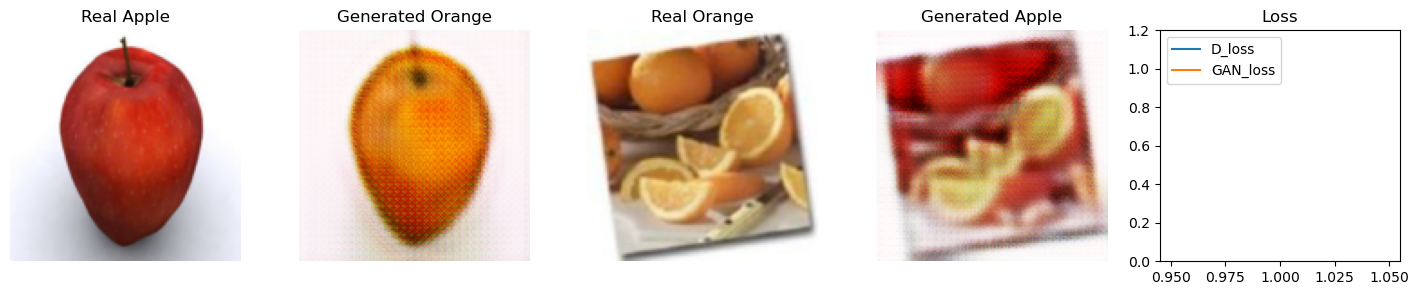

  0%|          | 1/200 [02:41<8:56:51, 161.87s/it]


KeyboardInterrupt: 

In [29]:
reset_seed(42)

# Hyperparameters
lr = 0.0001
n_epochs = 200
Lambda = 10

# Initialize models
G_AB = Generator().to(device) # Apple -> Orange
G_BA = Generator().to(device) # Orange -> Apple
D_A = Discriminator().to(device) # Classifies real/fake Apple
D_B = Discriminator().to(device) # Classifies real/fake Orange

# Optimizers
optimizer_G = torch.optim.Adam(itertools.chain(G_AB.parameters(), G_BA.parameters()), lr=lr)
optimizer_D_A = torch.optim.Adam(D_A.parameters(), lr=lr * 0.1)
optimizer_D_B = torch.optim.Adam(D_B.parameters(), lr=lr * 0.1)

# LR Schedulers
scheduler_G = torch.optim.lr_scheduler.LinearLR(optimizer_G, start_factor=1.0, end_factor=0.0, total_iters=0.5 * n_epochs)
scheduler_D_A = torch.optim.lr_scheduler.LinearLR(optimizer_D_A, start_factor=1.0, end_factor=0.0, total_iters=0.5 * n_epochs)
scheduler_D_B = torch.optim.lr_scheduler.LinearLR(optimizer_D_B, start_factor=1.0, end_factor=0.0, total_iters=0.5 * n_epochs)

# Lists to log metrics etc.
D_loss_list = []
G_loss_list = []
GAN_loss_list = []
epochnums = []

# Training Loop
for epoch in tqdm(range(1, n_epochs + 1)):
    curr_D_loss_list = []
    curr_G_loss_list = []
    curr_GAN_loss_list = []
    for i, batch in enumerate(train_dataloader):
        real_A = batch['A'].to(device)
        real_B = batch['B'].to(device)

        # ------------------
        #  Train Generators
        # ------------------
        optimizer_G.zero_grad()

        # GAN Loss (Adversarial)

        fake_B = G_AB(real_A)
        loss_GAN_AB = generator_loss(D_B(fake_B))

        fake_A = G_BA(real_B)
        loss_GAN_BA = generator_loss(D_A(fake_A))

        # Cycle Consistency Loss

        rec_A = G_BA(fake_B)
        rec_B = G_AB(fake_A)
        loss_cycle_A = cycle_consistency_loss(real_A, rec_A)
        loss_cycle_B = cycle_consistency_loss(real_B, rec_B)

        # Identity Loss (for color preservation)

        loss_id_A = identity_loss(real_A, G_BA(real_A))
        loss_id_B = identity_loss(real_B, G_AB(real_B))

        # Total Generator Loss
        loss_G = (loss_GAN_AB + loss_GAN_BA) + Lambda * (loss_cycle_A + loss_cycle_B) + 0.5 * Lambda * (loss_id_A + loss_id_B)

        # Train Generator G
        loss_G.backward()
        optimizer_G.step()

        # Train Discriminator A
        optimizer_D_A.zero_grad()
        loss_D_A = discriminator_loss(D_A(real_A), D_A(fake_A.detach()))
        loss_D_A.backward()
        optimizer_D_A.step()

        # Train Discriminator B

        optimizer_D_B.zero_grad()
        loss_D_B = discriminator_loss(D_B(real_B), D_B(fake_B.detach()))
        loss_D_B.backward()
        optimizer_D_B.step()

        curr_G_loss_list.append(loss_G.item())
        curr_D_loss_list.append(loss_D_A.item() + loss_D_B.item())
        curr_GAN_loss_list.append(loss_GAN_AB.item() + loss_GAN_BA.item())

    # Update learning rate
    if epoch >= 0.5 * n_epochs:
        scheduler_G.step()
        scheduler_D_A.step()
        scheduler_D_B.step()

    # Display images/plots/stats
    if (epoch - 1) % 10 == 0 or epoch == n_epochs:
        # Print stats
        print(f"[Epoch {epoch}/{n_epochs}] [D loss: {np.mean(curr_D_loss_list):.04f}] [G loss: {np.mean(curr_G_loss_list):.04f}] [GAN loss: {np.mean(curr_GAN_loss_list):.04f}]")
        # Plotting images
        plt.figure(figsize=(18,3))
        images = [real_A, fake_B, real_B, fake_A]
        titles = ['Real Apple', 'Generated Orange', 'Real Orange', 'Generated Apple']
        for i in range(4):
            plt.subplot(1, 5, i+1)
            img = images[i][0].cpu().detach().permute(1, 2, 0) * 0.5 + 0.5
            plt.imshow(img)
            plt.title(titles[i])
            plt.axis('off')
        # Plotting losses
        D_loss_list.append(np.mean(curr_D_loss_list))
        GAN_loss_list.append(np.mean(curr_GAN_loss_list))
        epochnums.append(epoch)
        plt.subplot(1, 5, 5)
        plt.plot(epochnums, D_loss_list, label="D_loss")
        plt.plot(epochnums, GAN_loss_list, label="GAN_loss")
        plt.ylim(0.0, 1.2)
        plt.title("Loss")
        plt.legend(loc='upper left')

        plt.show()

## Visualization
Show the qualitative results.


In [ ]:
def sample_images():
    """Saves a generated sample from the test set"""
    imgs = next(iter(test_dataloader))
    G_AB.eval()
    G_BA.eval()
    real_A = imgs['A'].to(device)
    real_B = imgs['B'].to(device)
    fake_B = G_AB(real_A)
    fake_A = G_BA(real_B)

    # Plotting
    images = [real_A, fake_B, real_B, fake_A]
    titles = ['Real Apple', 'Generated Orange', 'Real Orange', 'Generated Apple']
    for i in range(BATCH_SIZE):
        plt.figure(figsize=(8, 16))
        for j in range(4):
            plt.subplot(1, 4, j+1)
            img = images[j][i].cpu().detach().permute(1, 2, 0) * 0.5 + 0.5
            plt.imshow(img)
            plt.title(titles[j])
            plt.axis('off')
        plt.show()

sample_images()

## Convert Notebook to PDF

In [ ]:
# Generate and download a PDF for this notebook.
# Please provide the full path of the notebook file below (we have provided a default filename, but this might not match yours!)
#
# *If you run into problems running this code, please see this guide*: https://docs.google.com/document/d/1Y5SpnkX4Cp7bPL72CI9B5YSv5tUCiDHxVg3w0L5MXXU/edit?usp=sharing
notebook_path = '/content/drive/My Drive/Colab Notebooks/CycleGAN.ipynb' # UPDATE THIS

import os
drive_mount_point = '/content/drive/'
from google.colab import drive
drive.mount(drive_mount_point)
file_name = notebook_path.split('/')[-1]
get_ipython().system("apt update && apt install texlive-xetex texlive-fonts-recommended texlive-generic-recommended")
get_ipython().system("pip install pypandoc")
get_ipython().system("apt-get install texlive texlive-xetex texlive-latex-extra pandoc")
get_ipython().system("jupyter nbconvert --to PDF '{}'".format(notebook_path))

from google.colab import files
files.download(notebook_path.split('.')[0]+'.pdf')